<font size = 10>Analytical</font>

# Local run setup: Windows vs Mac (CUDA vs MPS)

Set the parameter below to match your machine:

- **Windows** → prefers **CUDA** (NVIDIA GPU) if available  
- **Mac** → prefers **MPS** (Apple Silicon GPU) if available  

If the preferred accelerator is not available, the notebook will **fall back to CPU**.

This notebook also includes plotting cells, so the helper `to_numpy(...)` safely moves tensors to CPU for Matplotlib when needed.


In [1]:
# ===== Platform / device selector =====
# Set this to: "Windows" or "Mac"
PLATFORM = "Mac"

# Set to False if you want to force CPU even when a GPU backend is available
USE_ACCELERATOR = True

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import torch
import matplotlib.pyplot as plt
# torch.set_printoptions(edgeitems=2, linewidth=75)

def pick_device(platform_choice: str, use_accelerator: bool = True) -> torch.device:
    if not use_accelerator:
        return torch.device("cpu")

    p = platform_choice.strip().lower()

    if p.startswith("mac"):
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")

    if p.startswith("win"):
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")

    raise ValueError('PLATFORM must be "Windows" or "Mac".')

DEVICE = pick_device(PLATFORM, USE_ACCELERATOR)

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def to_scalar(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().item()
    return float(x)

def make_params(w: float = 1.0, b: float = 0.0):
    return torch.tensor([w, b], dtype=torch.float32, device=DEVICE)

print(f"PLATFORM = {PLATFORM}")
print(f"USE_ACCELERATOR = {USE_ACCELERATOR}")
print(f"Selected DEVICE = {DEVICE}")

if DEVICE.type == "cuda":
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA devices available: {torch.cuda.device_count()}")
elif DEVICE.type == "mps":
    print("MPS backend is available (Apple Silicon GPU).")
else:
    print("Running on CPU.")


PLATFORM = Mac
USE_ACCELERATOR = True
Selected DEVICE = mps
MPS backend is available (Apple Silicon GPU).


# Define inputs and outputs for the model

In [2]:
t_c = torch.tensor([0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0],
                   dtype=torch.float32, device=DEVICE)
t_u = torch.tensor([35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4],
                   dtype=torch.float32, device=DEVICE)
print(f"t_c device: {t_c.device}, t_u device: {t_u.device}")

t_c device: mps:0, t_u device: mps:0


## Model
$$\huge m = w \cdot t_u + b$$

$$\huge \frac {\partial m}{\partial w} = t_u $$

$$\huge \frac {\partial m}{\partial b} = 1 $$


In [3]:
def model(t_u, w, b):
    return t_u*w + b

def dmodel_dw(t_u, w, b):
    return t_u

def dmodel_db(t_u, w, b):
    return 1

## Loss
$$\huge loss(t_u, t_c) = [m(t_u) - t_c]^2$$
$$\huge \frac {\partial loss(t_u, t_c)}{\partial m} = 2 \cdot [m(t_u) - t_c] $$

In [4]:
def loss_fn(t_p, t_c):
    return torch.mean(torch.square(t_p-t_c))

def dloss_fn_dm(t_p, t_c):
    return (2*(t_p-t_c)) / t_p.shape[0] # 1/N is from the mean. 

## Gradient
$$\huge \nabla _{w,b}L(w,b, t_u, t_c) = \left(\frac{\partial L}{\partial w},\frac{\partial L}{\partial b}\right)=\left(\frac{\partial L}{\partial m}\cdot\frac{\partial m}{\partial w}, \frac{\partial L}{\partial m}\cdot\frac{\partial m}{\partial b}\right)$$

In [5]:
def grad_fn(t_u, t_c, t_p, w, b):
    dloss_dm = dloss_fn_dm(t_p, t_c)
    dloss_dw = dloss_dm * dmodel_dw(t_u, w, b)
    dloss_db = dloss_dm * dmodel_db(t_u, w, b)
    return torch.stack([dloss_dw.sum(), dloss_db.sum()])

## The Training Loop
$$\huge w_{t+1} = w_t - lr \cdot \nabla _{w}L $$
$$\huge b_{t+1} = b_t - lr \cdot \nabla _{b}L $$

In [6]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        w, b = params
        t_p = model(t_u, w, b) # forward pass: compute the model prediction
        loss = loss_fn(t_p, t_c) # computre the loss (to monitor conversion)
        grad = grad_fn(t_u, t_c, t_p, w, b) #  backward pass: use local loss gradient to
                                            # compute how loss responds to parameter changes
        params = params - learning_rate * grad # update parameters
        if (epoch-1) % 10 ==0:
            print('Epoch %d, Loss %f' % (epoch, to_scalar(loss)))
    return params

# Run the model

In [7]:
training_loop(
        n_epochs = 100, 
        learning_rate = 1e-4,
        params = make_params(1.0, 0.0), # (w_0, b_0)
        t_u = t_u,
        t_c = t_c)

Epoch 1, Loss 1763.884644
Epoch 11, Loss 29.104170
Epoch 21, Loss 29.094963
Epoch 31, Loss 29.085804
Epoch 41, Loss 29.076647
Epoch 51, Loss 29.067486
Epoch 61, Loss 29.058332
Epoch 71, Loss 29.049183
Epoch 81, Loss 29.040039
Epoch 91, Loss 29.030891


tensor([ 0.2327, -0.0438], device='mps:0')

## Plot convergence

In [8]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    log = []
    for epoch in range(1, n_epochs + 1):
        w, b = params
        t_p = model(t_u, w, b) # forward pass: compute the model prediction
        loss = loss_fn(t_p, t_c) # compute the loss (to monitor convergence)
        grad = grad_fn(t_u, t_c, t_p, w, b) # backward pass: use local loss gradient to
                                            # compute how loss responds to parameter changes
        params = params - learning_rate * grad # update parameters

        log.append(torch.stack([
            torch.tensor(float(epoch), dtype=params.dtype, device=params.device),
            loss.detach(),
            params[0].detach(),
            params[1].detach(),
            grad[0].detach(),
            grad[1].detach()
        ])) # epoch, loss, w, b, grad_w, grad_b
    return params, torch.stack(log)

In [9]:
params, log = training_loop(
        n_epochs = 100, 
        learning_rate = 1e-4,
        params = make_params(1.0, 0.0),
        t_u = t_u,
        t_c = t_c)
print(f"w={to_scalar(params[0]):3.3f}, b={to_scalar(params[1]):3.3f}")

w=0.233, b=-0.044


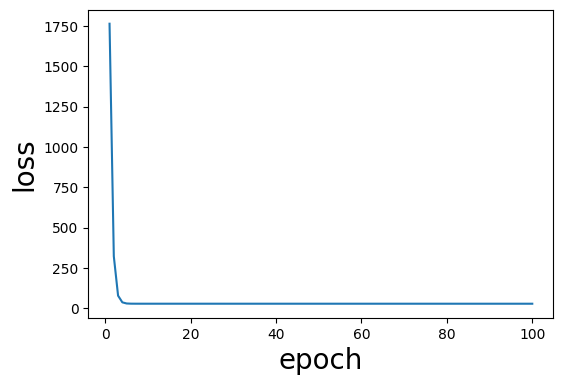

In [10]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(to_numpy(log[:,0]), to_numpy(log[:,1]))
ax.set_xlabel('epoch', fontsize=20);
ax.set_ylabel('loss', fontsize=20);

In [11]:
def plot_progress(log):
    log_np = to_numpy(log)

    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(log_np[:,0], log_np[:,1])
    ax.set_xlabel('epoch', fontsize=20);
    ax.set_ylabel('loss', fontsize=20);

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,9))
    axes[0,0].plot(log_np[:,0], log_np[:,2])
    axes[0,0].set_xlabel('epoch', fontsize=20);
    axes[0,0].set_ylabel('w', fontsize=20);

    axes[0,1].plot(log_np[:,0], log_np[:,3])
    axes[0,1].set_xlabel('epoch', fontsize=20);
    axes[0,1].set_ylabel('b', fontsize=20);

    axes[1,0].plot(log_np[:,0], log_np[:,4])
    axes[1,0].set_xlabel('epoch', fontsize=20);
    axes[1,0].set_ylabel(r'$\nabla _{w}L$', fontsize=20);

    axes[1,1].plot(log_np[:,0], log_np[:,5])
    axes[1,1].set_xlabel('epoch', fontsize=20);
    axes[1,1].set_ylabel(r'$\nabla _{b}L$', fontsize=20);

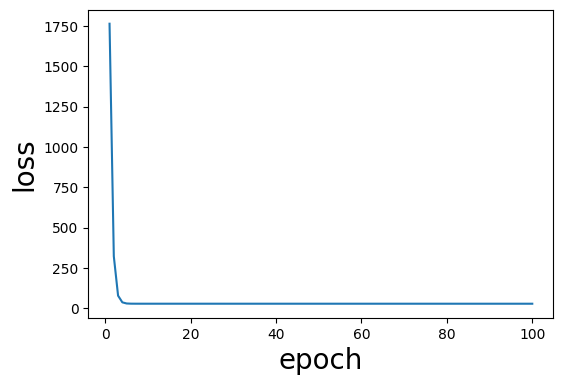

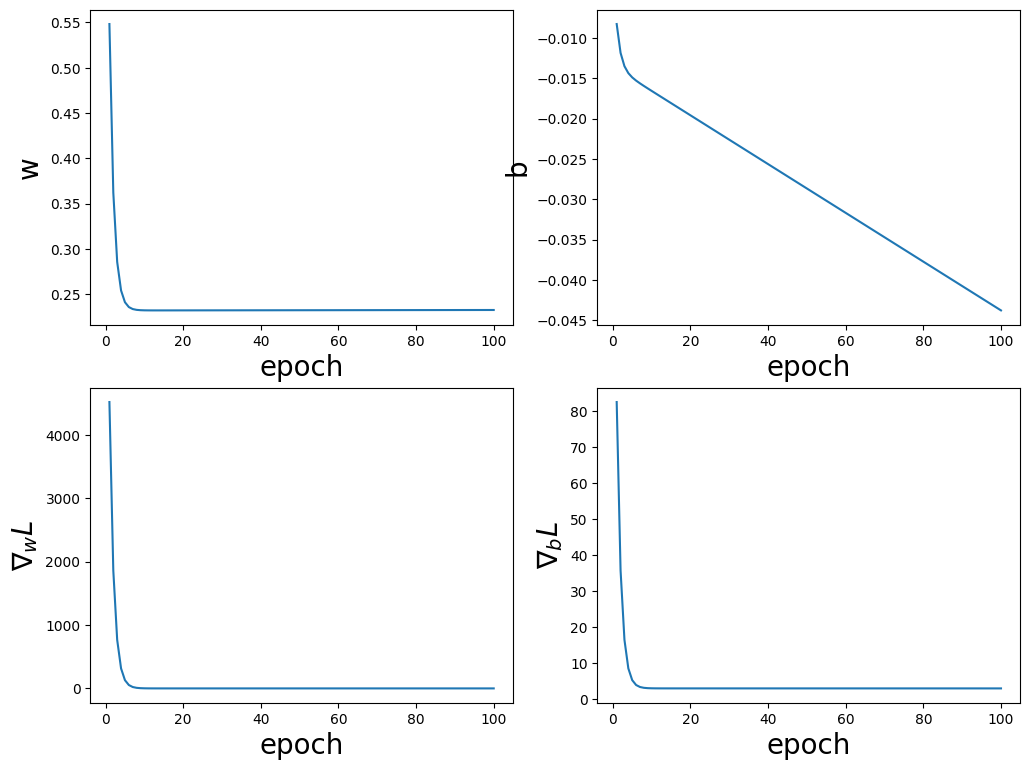

In [12]:
plot_progress(log)

Notes: 

- The procedure is MUCH faster than complete enumeration. 
- It did not converge to the correct values (0.5556, -17.78). The loss function is very high!

Why? 
- The training loop performance is very sensitive to the learning rate. With proper learning rate, the parameter updates get very small. So, we need adaptive $lr$. 
- Another problem: The extremely different values of the gradients for $w$ and $w$: $\nabla _{w}L >> \nabla _{b}L$<br>
This suggests that each parameter must have a different $lr$. 

Solutions:
- Separate $lr$ for each parameter or parameter normalization. 
- Alternatively, normalize the inputs. 
- Increase the number of iterations. Perhaps, the model did not yet converge?

# Normalizing inputs
$\Large t_u \Rightarrow \frac {t_u-mean(t_u)}{std(t_u)} $
Note faster convergence, even with higher learning rate. 

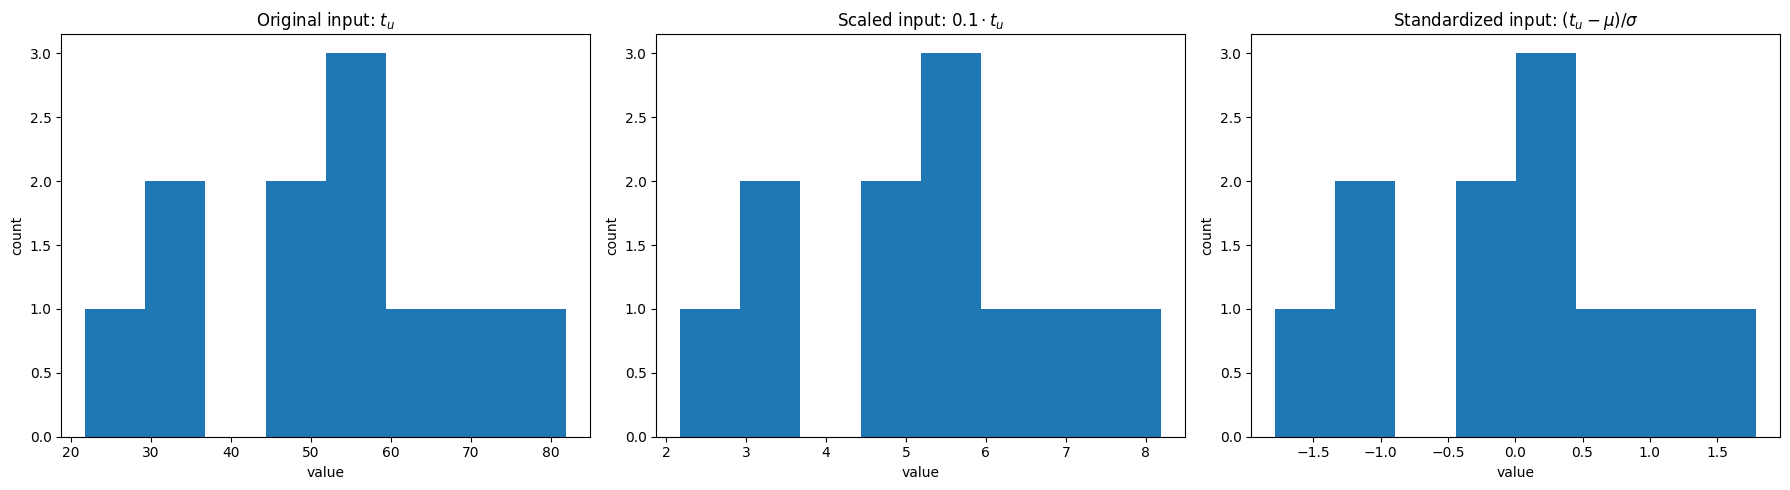

Summary statistics
Original       -> mean = 51.800, std = 16.832
Scaled (0.1x)  -> mean = 5.180, std = 1.683
Standardized   -> mean = -0.000, std = 1.000


In [20]:
import matplotlib.pyplot as plt
import torch

# Original and normalized versions of the input
t_u_original = t_u
t_u_scaled_01 = 0.1 * t_u
t_u_standardized = (t_u - t_u.mean()) / t_u.std()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original
axes[0].hist(t_u_original.detach().cpu().numpy(), bins=8)
axes[0].set_title('Original input: $t_u$')
axes[0].set_xlabel('value')
axes[0].set_ylabel('count')

# Scaled by 0.1
axes[1].hist(t_u_scaled_01.detach().cpu().numpy(), bins=8)
axes[1].set_title('Scaled input: $0.1 \\cdot t_u$')
axes[1].set_xlabel('value')
axes[1].set_ylabel('count')

# Standardized
axes[2].hist(t_u_standardized.detach().cpu().numpy(), bins=8)
axes[2].set_title('Standardized input: $(t_u-\\mu)/\\sigma$')
axes[2].set_xlabel('value')
axes[2].set_ylabel('count')

plt.tight_layout()
plt.show()

print("Summary statistics")
print(f"Original       -> mean = {t_u_original.mean().item():.3f}, std = {t_u_original.std().item():.3f}")
print(f"Scaled (0.1x)  -> mean = {t_u_scaled_01.mean().item():.3f}, std = {t_u_scaled_01.std().item():.3f}")
print(f"Standardized   -> mean = {t_u_standardized.mean().item():.3f}, std = {t_u_standardized.std().item():.3f}")

w=2.755, b=-2.516


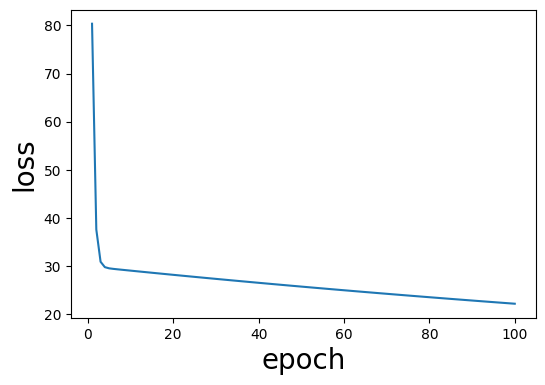

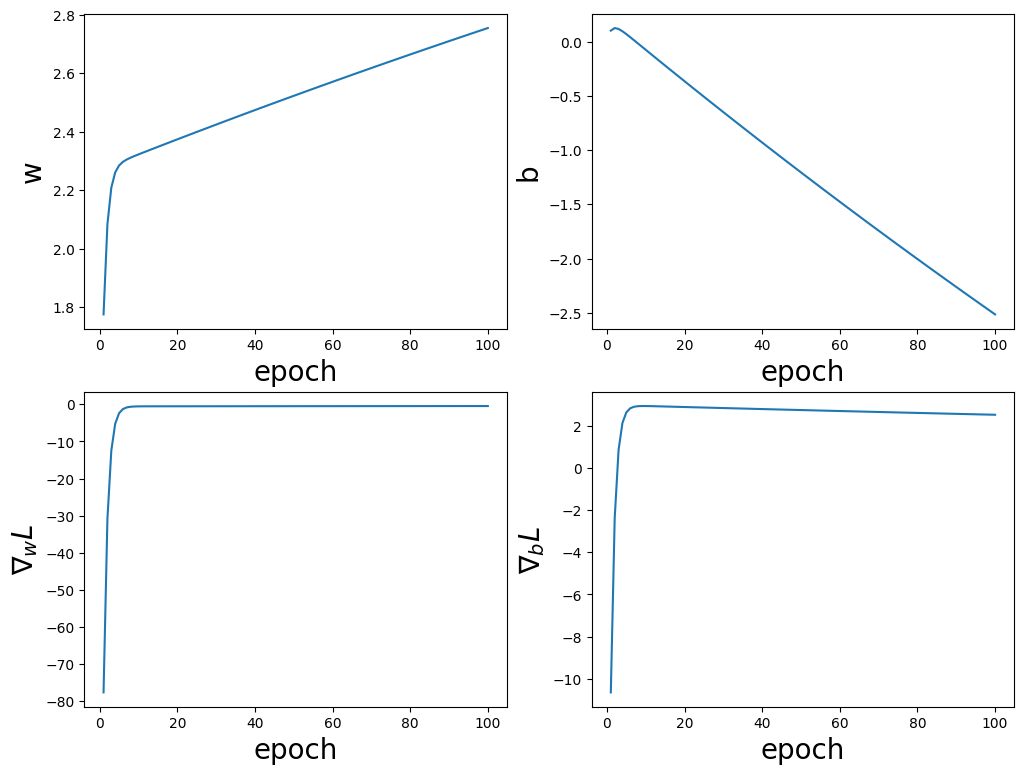

In [13]:
params, log = training_loop(
        n_epochs = 100, 
        learning_rate = 1e-2,
        params = make_params(1.0, 0.0),
        t_u = 0.1*t_u, # or (t_u-t_u.mean())/t_u.std(),
        t_c = t_c)
print(f"w={to_scalar(params[0]):3.3f}, b={to_scalar(params[1]):3.3f}")
plot_progress(log)

w=5.367, b=-17.301


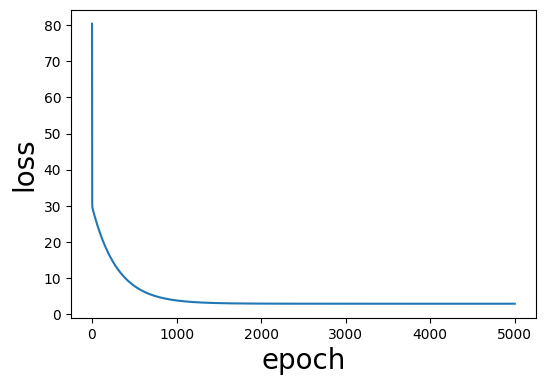

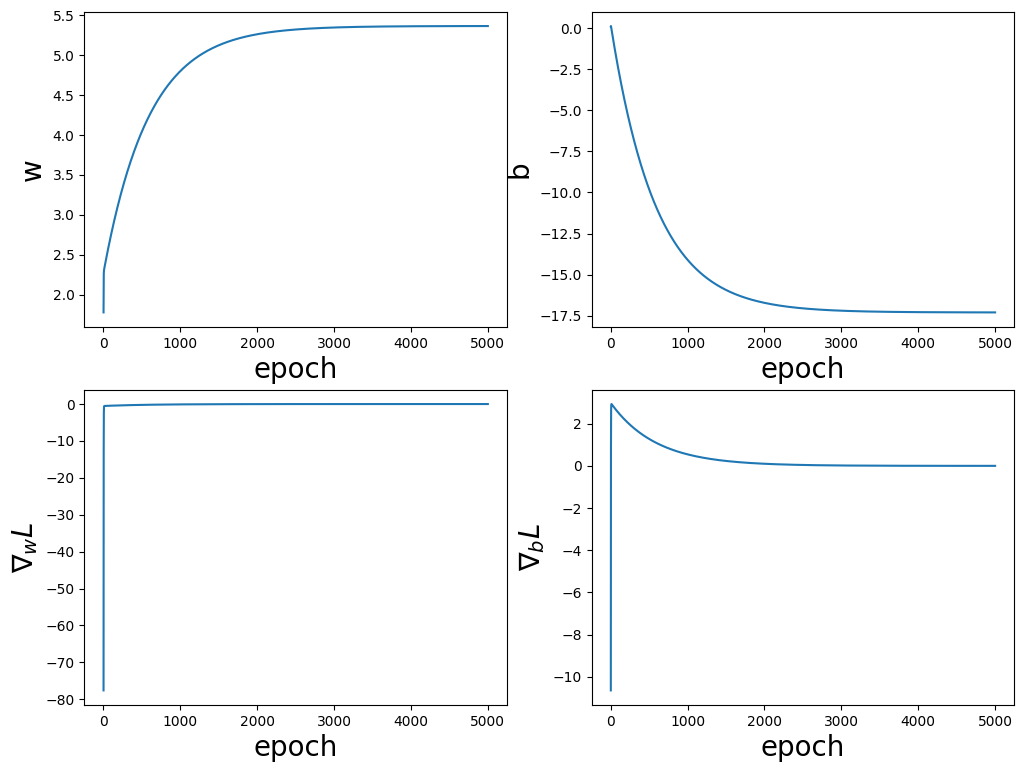

In [14]:
params, log = training_loop(
        n_epochs = 5000, 
        learning_rate = 1e-2,
        params = make_params(1.0, 0.0),
        t_u = 0.1*t_u, #(t_u-t_u.mean())/t_u.std(),
        t_c = t_c)
print(f"w={to_scalar(params[0]):3.3f}, b={to_scalar(params[1]):3.3f}")
plot_progress(log)

w=9.035, b=10.500


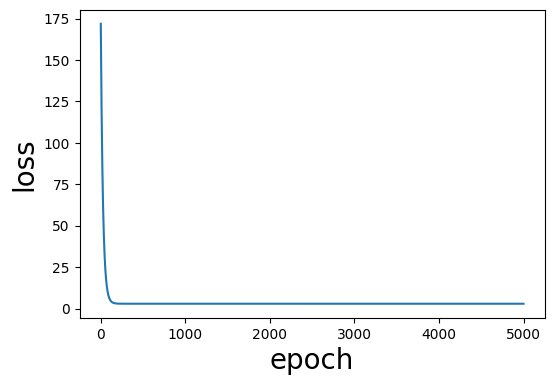

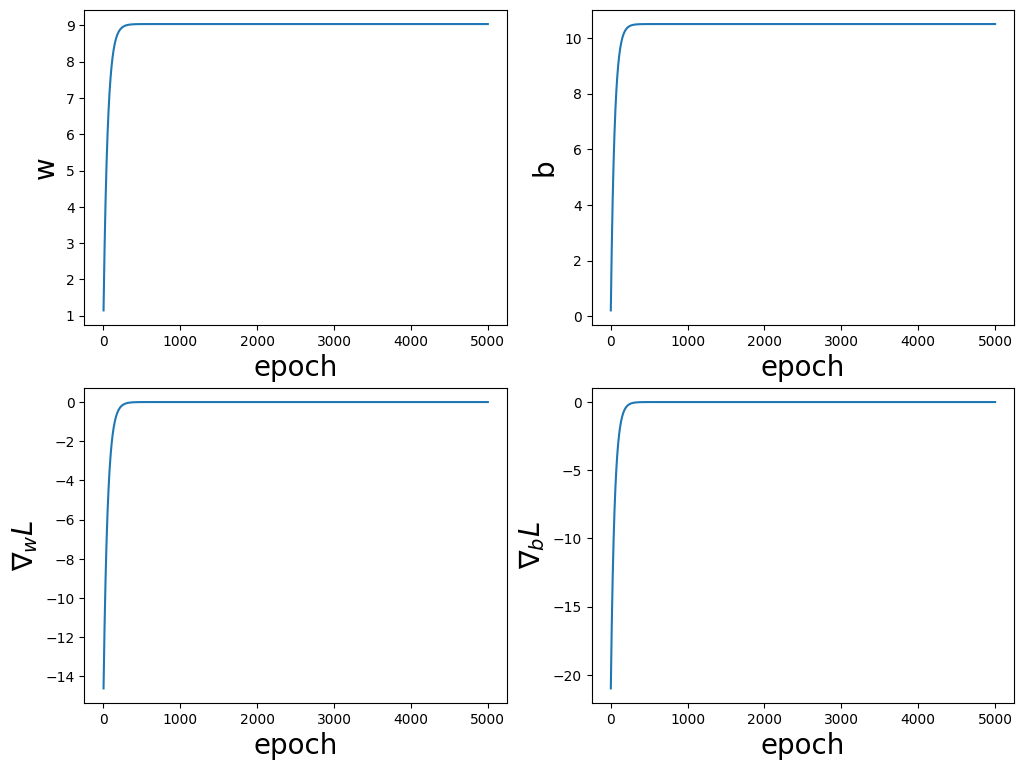

In [15]:
params, log1 = training_loop(
        n_epochs = 5000, 
        learning_rate = 1e-2,
        params = make_params(1.0, 0.0),
        t_u = (t_u-t_u.mean())/t_u.std(),
        t_c = t_c)
print(f"w={to_scalar(params[0]):3.3f}, b={to_scalar(params[1]):3.3f}")
plot_progress(log1)

w=0.258, b=-1.463


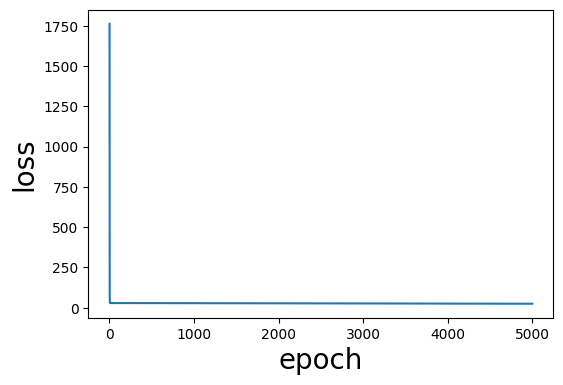

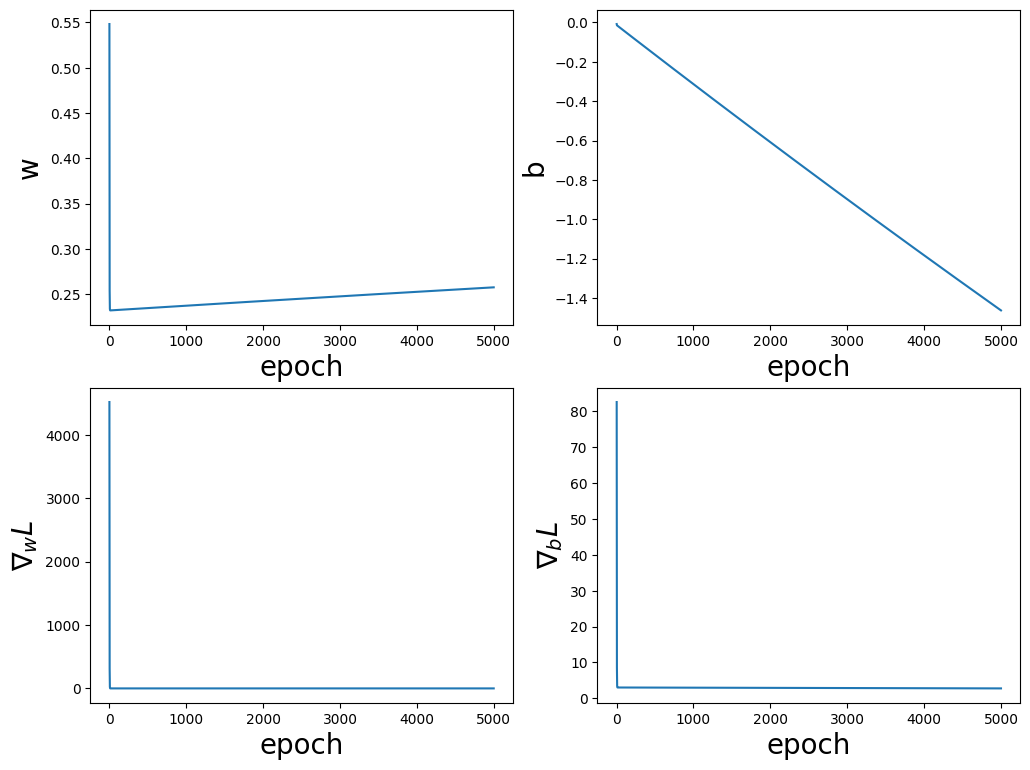

In [16]:
params, log2 = training_loop(
        n_epochs = 5000, 
        learning_rate = 1e-4,
        params = make_params(1.0, 0.0),
        t_u =t_u, #(t_u-t_u.mean())/t_u.std(),
        t_c = t_c)
print(f"w={to_scalar(params[0]):3.3f}, b={to_scalar(params[1]):3.3f}")
plot_progress(log2)

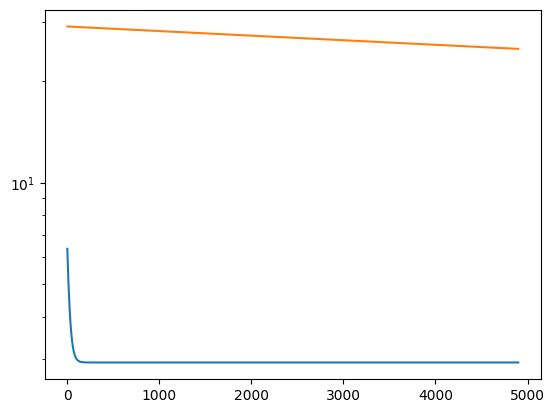

In [17]:
plt.semilogy(to_numpy(log1[100:,1]))
plt.semilogy(to_numpy(log2[100:,1]))

In [18]:
log1[100:,1]-log2[100:,1]

tensor([-22.6595, -22.7893, -22.9141,  ..., -21.9816, -21.9809, -21.9801],
       device='mps:0')

In [19]:
log1[:,1],log2[:,1],

(tensor([171.8683, 165.3876, 159.1560,  ...,   2.9276,   2.9276,   2.9276],
        device='mps:0'),
 tensor([1763.8846,  323.0905,   78.9296,  ...,   24.9093,   24.9085,
           24.9077], device='mps:0'))